In [29]:
import sys
import os
PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

import random
import glob
import cv2
import matplotlib.pyplot as plt

from src.preprocessing import MediaPipeExtractor

In [30]:
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20)
]

def draw_hand_from_features(image, features, hand_idx=0):
    h, w, _ = image.shape
    offset = hand_idx * 21 * 3
    points = []

    for i in range(21):
        x = int(features[offset + i*3] * w)
        y = int(features[offset + i*3 + 1] * h)
        points.append((x, y))
        cv2.circle(image, (x, y), 4, (0,255,0), -1)

    for a, b in HAND_CONNECTIONS:
        cv2.line(image, points[a], points[b], (255,0,0), 2)

    return image

In [31]:
import os
os.getcwd()

'/Users/belhajali/Desktop/Exjobb Master/SLR/Cloud-based-SLR/Cloud-based-SLR/notebooks'

In [41]:
IMAGE_DIR = "/Users/belhajali/Desktop/Exjobb Master/SLR/Cloud-based-SLR/Cloud-based-SLR/data/preprocessing/test/frames/birthday/06360/*.jpg"
image_paths = glob.glob(IMAGE_DIR)#image_paths = glob.glob(IMAGE_DIR)
# = glob.glob(IMAGE_DIR, recursive=True)

print("Antal bilder hittade:", len(image_paths))
image_paths[:6]



Antal bilder hittade: 16


['/Users/belhajali/Desktop/Exjobb Master/SLR/Cloud-based-SLR/Cloud-based-SLR/data/preprocessing/test/frames/birthday/06360/birthday_8.jpg',
 '/Users/belhajali/Desktop/Exjobb Master/SLR/Cloud-based-SLR/Cloud-based-SLR/data/preprocessing/test/frames/birthday/06360/birthday_9.jpg',
 '/Users/belhajali/Desktop/Exjobb Master/SLR/Cloud-based-SLR/Cloud-based-SLR/data/preprocessing/test/frames/birthday/06360/birthday_15.jpg',
 '/Users/belhajali/Desktop/Exjobb Master/SLR/Cloud-based-SLR/Cloud-based-SLR/data/preprocessing/test/frames/birthday/06360/birthday_14.jpg',
 '/Users/belhajali/Desktop/Exjobb Master/SLR/Cloud-based-SLR/Cloud-based-SLR/data/preprocessing/test/frames/birthday/06360/birthday_13.jpg',
 '/Users/belhajali/Desktop/Exjobb Master/SLR/Cloud-based-SLR/Cloud-based-SLR/data/preprocessing/test/frames/birthday/06360/birthday_12.jpg']

In [33]:
extractor = MediaPipeExtractor()

I0000 00:00:1770292787.534467  247624 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
W0000 00:00:1770292787.543438  247633 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770292787.552791  247633 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1770292787.567206  247636 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
W0000 00:00:1770292787.621481  247640 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770292787.630631  247641 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


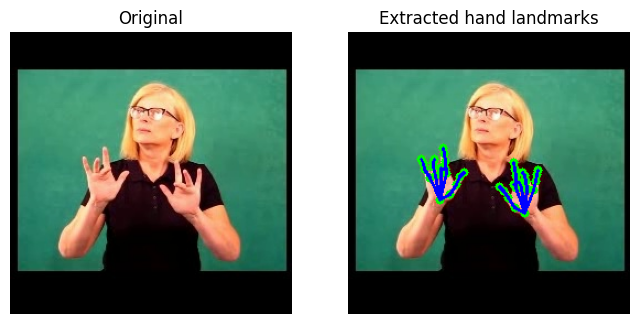

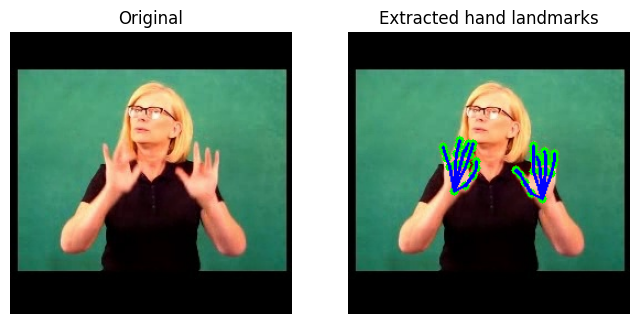

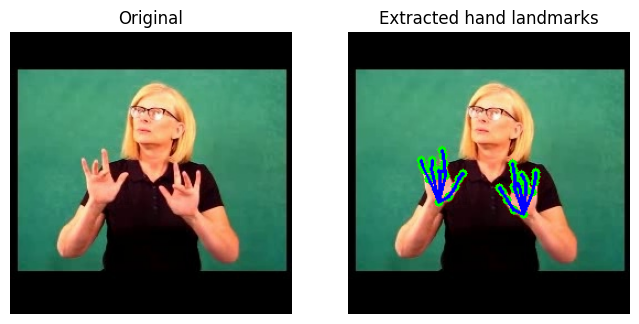

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

IMAGE_DIR = "/Users/belhajali/Desktop/Exjobb Master/SLR/Cloud-based-SLR/Cloud-based-SLR/data/preprocessing/test/frames/computer/12320/*.jpg"
image_paths = glob.glob(IMAGE_DIR)#image_paths = glob.glob(IMAGE_DIR)


for img_path in random.sample(image_paths, 3
                              
                              
                              
                              ):
    image = cv2.imread(img_path)

    if image is None:
        print("Kunde inte läsa:", img_path)
        continue

    features = extractor.extract_features(img_path)
    vis = image.copy()
    vis = draw_hand_from_features(vis, features, hand_idx=0)
    vis = draw_hand_from_features(vis, features, hand_idx=1)
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Extracted hand landmarks")
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.show()

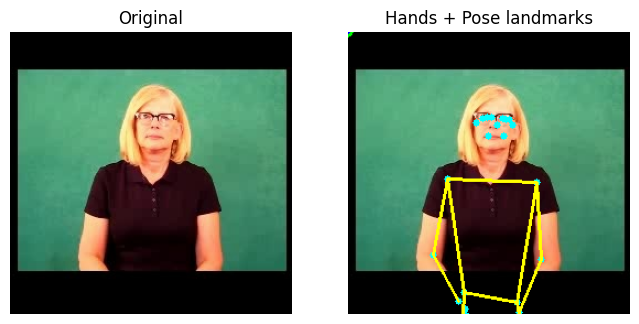

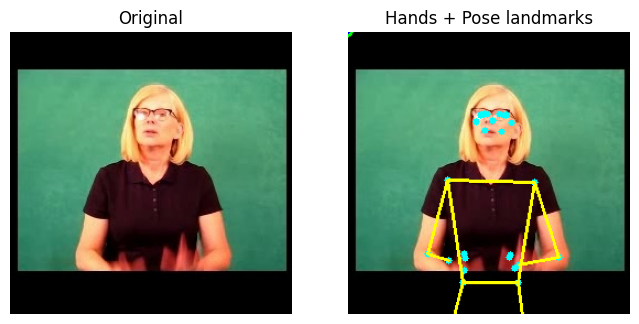

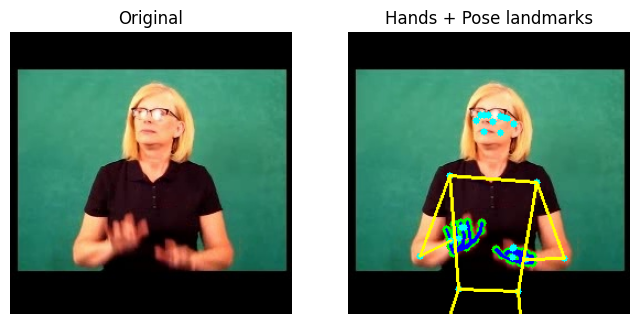

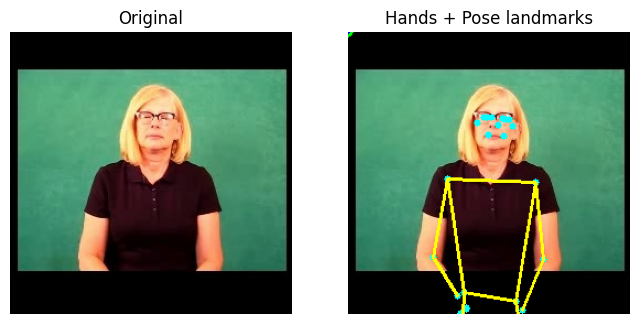

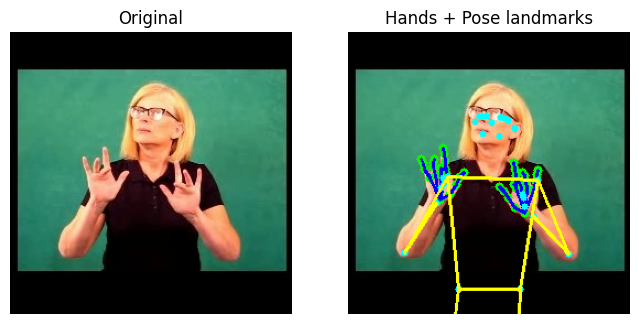

In [51]:
POSE_CONNECTIONS = [
    (11,13),(13,15),   # left arm
    (12,14),(14,16),   # right arm
    (11,12),           # shoulders
    (11,23),(12,24),   # torso
    (23,24),           # hips
    (23,25),(25,27),   # left leg
    (24,26),(26,28)    # right leg
]
def draw_pose_from_features(image, features):
    h, w, _ = image.shape

    pose_offset = 2 * 21 * 3  # två händer
    points = []

    for i in range(33):
        x = int(features[pose_offset + i*3] * w)
        y = int(features[pose_offset + i*3 + 1] * h)
        points.append((x, y))
        cv2.circle(image, (x, y), 3, (255,255,0), -1)

    for a, b in POSE_CONNECTIONS:
        cv2.line(image, points[a], points[b], (0,255,255), 2)

    return image

vis = image.copy()

# båda händerna
vis = draw_hand_from_features(vis, features, hand_idx=0)
vis = draw_hand_from_features(vis, features, hand_idx=1)

# hela kroppen
vis = draw_pose_from_features(vis, features)
for img_path in random.sample(image_paths, 5):
    image = cv2.imread(img_path)

    if image is None:
        print("Kunde inte läsa:", img_path)
        continue

    features = extractor.extract_features(img_path)

    vis = image.copy()

    # båda händerna
    vis = draw_hand_from_features(vis, features, hand_idx=0)
    vis = draw_hand_from_features(vis, features, hand_idx=1)

    # hela kroppen (pose)
    vis = draw_pose_from_features(vis, features)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Hands + Pose landmarks")
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.show()